```
Classification
K-NN:-K Nearest Nieghbor
k always take odd so no tie in decision

CM=[[TN  FP]
    [FN  TP]]

Specifity(Numerator)=TN/(TN+FP)
Sensitivity(Denomerator)=TP/(FN+TP)
precision_score=TP/(TP+FP)
pros_label=1 ----> for positive
```

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [2]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
y=df['Outcome']
print(type(y))
x=df.drop(['Outcome'],axis=1)

<class 'pandas.core.series.Series'>


In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=1)
nn=KNeighborsClassifier(n_neighbors=5)
nn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [6]:
ypred=nn.predict(x_test)
ypred

array([1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [7]:
cm=confusion_matrix(y_test,ypred)
cm

array([[82, 17],
       [24, 31]])

In [8]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,TP,FN,FP)

82 31 24 17


In [9]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
precision_score=TP/(TP+FP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("Precision Score:",precision_score)

Specificity: 0.8282828282828283
Sensitivity: 0.5636363636363636
Precision Score: 0.6458333333333334


In [10]:
print("accuracy score:",accuracy_score(y_test,ypred))

accuracy score: 0.7337662337662337


In [11]:
accuracy=[]
for i in range(1,30):
    nn=KNeighborsClassifier(n_neighbors=i)
    nn.fit(x_train,y_train)
    ypred=nn.predict(x_test)
    accuracy.append(accuracy_score(y_test,ypred))

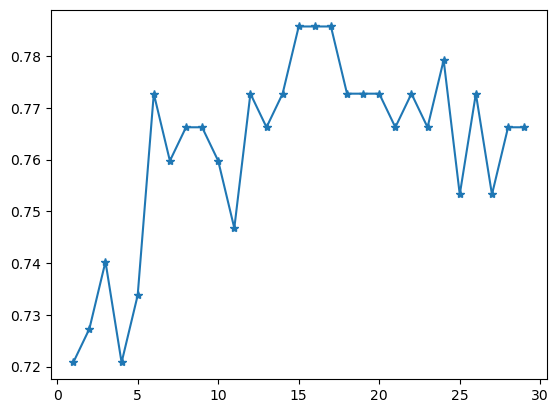

In [12]:
plt.plot(range(1,30),accuracy,marker='*')
plt.show()

In [13]:
print(accuracy)

[0.7207792207792207, 0.7272727272727273, 0.7402597402597403, 0.7207792207792207, 0.7337662337662337, 0.7727272727272727, 0.7597402597402597, 0.7662337662337663, 0.7662337662337663, 0.7597402597402597, 0.7467532467532467, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7857142857142857, 0.7857142857142857, 0.7857142857142857, 0.7727272727272727, 0.7727272727272727, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7662337662337663, 0.7792207792207793, 0.7532467532467533, 0.7727272727272727, 0.7532467532467533, 0.7662337662337663, 0.7662337662337663]


___

In [14]:
df=pd.read_csv("tshirt.csv")
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Height  18 non-null     int64 
 1   Wight   18 non-null     int64 
 2   Size    18 non-null     object
dtypes: int64(2), object(1)
memory usage: 564.0+ bytes


In [16]:
df.isna().sum()

Height    0
Wight     0
Size      0
dtype: int64

In [17]:
y=df['Size']
x=df.drop(['Size'],axis=1)

In [18]:
x

,Height,Wight
0,158,58
1,158,59
2,158,63
3,160,59
4,160,60
5,163,60
6,163,61
7,160,64
8,163,64
9,165,61


In [19]:
nn=KNeighborsClassifier(n_neighbors=5)
nn.fit(x,y)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
ypred=nn.predict(x)
ypred

array(['M', 'M', 'M', 'M', 'M', 'M', 'L', 'M', 'L', 'L', 'L', 'L', 'L',
       'L', 'L', 'L', 'L', 'L'], dtype=object)

In [21]:
cm=confusion_matrix(y,ypred)
cm

array([[10,  1],
       [ 1,  6]])

In [22]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [23]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)

Specificity: 0.9090909090909091
Sensitivity: 0.8571428571428571


In [24]:
print("accuracy score:",accuracy_score(y,ypred))

accuracy score: 0.8888888888888888


In [25]:
pre=TP/(TP+FP)
print("Precision Score:",pre)#in this it take by defalt 1=m in pos label
print("Precision Score(M):", metrics.precision_score(y,ypred,pos_label='M'))
print("Precision Score:(L)", metrics.precision_score(y,ypred,pos_label='L'))

Precision Score: 0.8571428571428571
Precision Score(M): 0.8571428571428571
Precision Score:(L) 0.9090909090909091


___

# Decision Tree

```
there are total three node
1) root
2) decision 
3) leaf
antropy formula
in this label data so first we have to convert num data
leaf node is last node and its accuracy is always 100
leaf node entropy is 0,0
if i'm use max_depth then its accuray is not 100


data ne category mathi numeric ma lavvu ---- feature transform
df['column_name']=np.where(condition,[x,y])
```

In [26]:
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CGPA               18 non-null     int64
 1   Communication      18 non-null     int64
 2   Apptitude          18 non-null     int64
 3   Programming Skill  18 non-null     int64
 4   Job Offered        18 non-null     int64
dtypes: int64(5)
memory usage: 852.0 bytes


In [28]:
df.isna().sum()

CGPA                 0
Communication        0
Apptitude            0
Programming Skill    0
Job Offered          0
dtype: int64

In [29]:
x=df.drop("Job Offered",axis=1)
x

,CGPA,Communication,Apptitude,Programming Skill
0,2,1,1,1
1,1,1,1,1
2,0,0,0,1
3,0,1,0,0
4,2,1,1,0
5,2,1,1,1
6,1,0,0,0
7,1,0,0,1
8,2,0,1,1
9,1,1,1,1


In [30]:
y=df['Job Offered']
y

0     1
1     1
2     0
3     0
4     1
5     1
6     0
7     0
8     1
9     1
10    0
11    0
12    1
13    0
14    0
15    0
16    0
17    1
Name: Job Offered, dtype: int64

In [31]:
type(y)

pandas.core.series.Series

In [32]:
dt=DecisionTreeClassifier(criterion="entropy")
model=dt.fit(x,y)
model

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
ypred=dt.predict(x)
ypred

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [34]:
diff=pd.DataFrame({"Actual":y,"Prediction":ypred})
diff

,Actual,Prediction
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


In [35]:
cm=confusion_matrix(y,ypred)
cm

array([[10,  0],
       [ 0,  8]])

In [36]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [37]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("accuracy score:",accuracy_score(y,ypred))
print("precision score:",metrics.precision_score(y,ypred))

Specificity: 1.0
Sensitivity: 1.0
accuracy score: 1.0
precision score: 1.0


In [38]:
plt.figure(figsize=(20,10))
plt.show()

<Figure size 2000x1000 with 0 Axes>

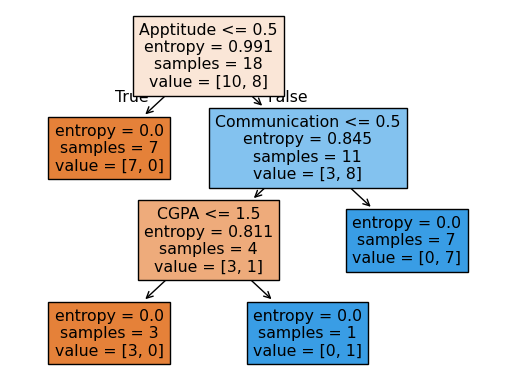

In [39]:
fea=x.columns
plot_tree(dt,feature_names=fea,filled=True)
plt.show()

___

In [40]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [41]:
x=df.drop('Outcome',axis=1)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [42]:
y=df['Outcome']
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [44]:
dt=DecisionTreeClassifier(criterion="entropy")
model=dt.fit(x_train,y_train)
model

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
ypred=dt.predict(x_test)
ypred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1])

In [46]:
cm=confusion_matrix(y_test,ypred)
cm

array([[75, 24],
       [22, 33]])

In [47]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

75 24 22 33


In [48]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("accuracy score:",accuracy_score(y_test,ypred))
print("precision score:",metrics.precision_score(y_test,ypred))

Specificity: 0.7575757575757576
Sensitivity: 0.6
accuracy score: 0.7012987012987013
precision score: 0.5789473684210527


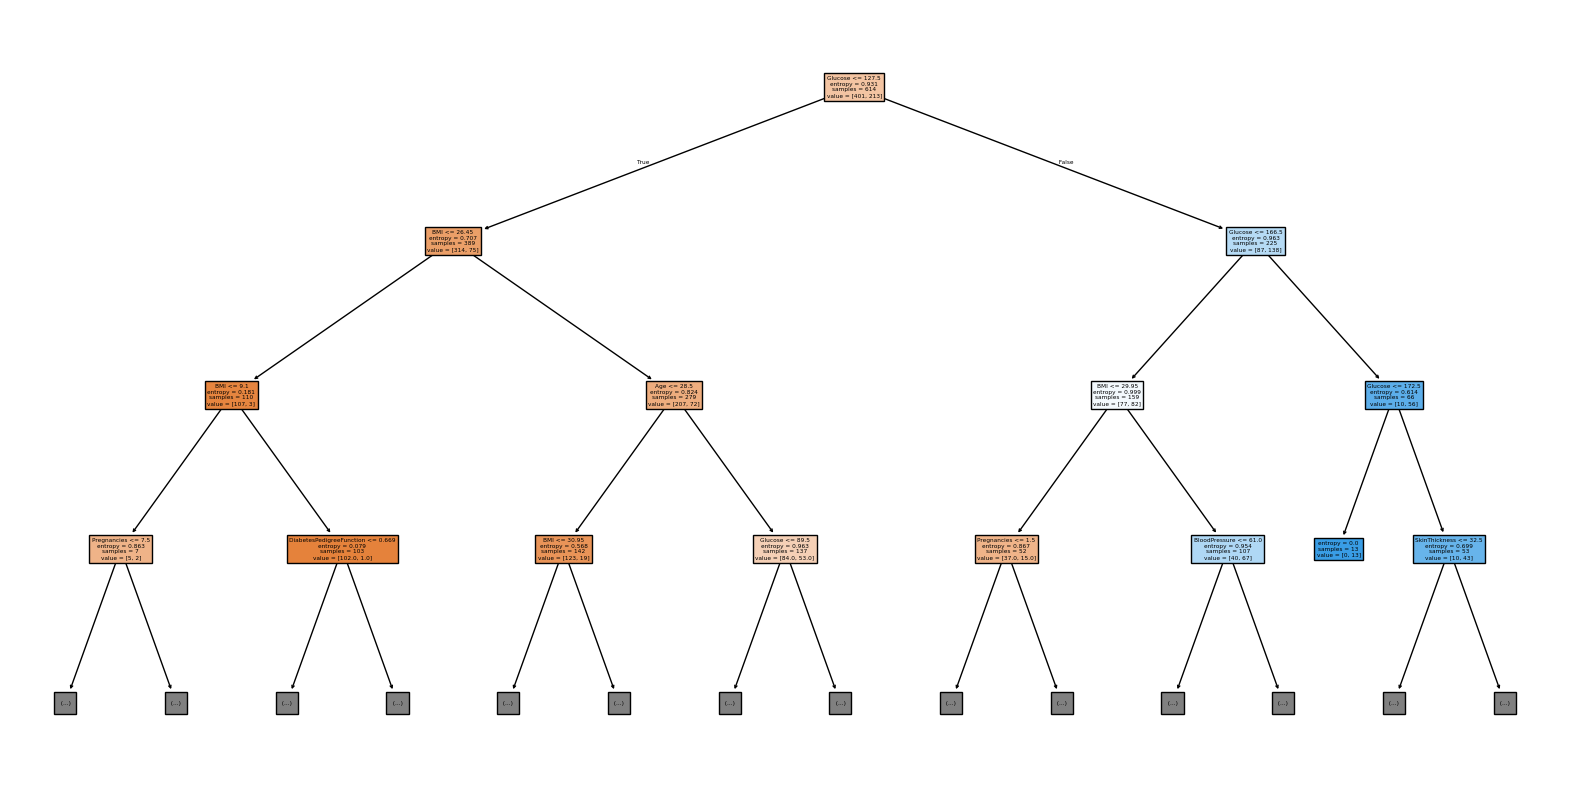

In [49]:
plt.figure(figsize=(20,10))
fea=x.columns
plot_tree(dt,feature_names=fea,filled=True,max_depth=3)
plt.show()

In [52]:
from sklearn import tree
calculation=tree.export_text(dt,feature_names=fea)
print(calculation)

|--- Glucose <= 127.50
|   |--- BMI <= 26.45
|   |   |--- BMI <= 9.10
|   |   |   |--- Pregnancies <= 7.50
|   |   |   |   |--- class: 0
|   |   |   |--- Pregnancies >  7.50
|   |   |   |   |--- class: 1
|   |   |--- BMI >  9.10
|   |   |   |--- DiabetesPedigreeFunction <= 0.67
|   |   |   |   |--- class: 0
|   |   |   |--- DiabetesPedigreeFunction >  0.67
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.71
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- DiabetesPedigreeFunction >  0.71
|   |   |   |   |   |--- class: 0
|   |--- BMI >  26.45
|   |   |--- Age <= 28.50
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- Pregnancies <= 7.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Pregnancies >  7.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- Age <= 22.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age >  22.50
|   |   |   |   |   |--- BMI <= 45.40
|   |   |   |   |   |   |--- BMI <= 38.35
|   |   |   |   |   |   |

___